In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StringType
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import os, time, warnings
warnings.filterwarnings("ignore")
 
OUT_DIR     = "eda_advanced"
PARQUET_DIR = "data_parquet"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# CELL 1 — SPARK SESSION
# Tuned for: 40 cores, 4096 fd limit, /var scratch
# ────────────────────────────────────────────────────────────────
try:
    SparkSession.getActiveSession().stop()
    import time; time.sleep(2)
except:
    pass
 
# fd budget calculation:
#   local[8] → 8 concurrent tasks
#   shuffle.partitions=16 → 16 reducer files per task
#   16 × 8 = 128 shuffle files + ~250 JVM baseline = ~378 total
#   378 << 4096 ✓
spark = (SparkSession.builder
    .appName("AlibabaEDA-lily")
 
    # Use 8 of 40 cores — leave rest for other users on shared node
    .master("local[8]")
 
    # Memory — /proc/meminfo on CentOS 7 shared node
    # Assume ~128GB RAM shared; take 30GB conservatively
    .config("spark.driver.memory",                   "12g")
    .config("spark.executor.memory",                 "16g")
    .config("spark.executor.memoryOverhead",         "3g")
    .config("spark.driver.maxResultSize",            "6g")
 
    # ── fd limit fix ──
    # 16 shuffle partitions × 8 threads = 128 files max
    .config("spark.sql.shuffle.partitions",          "32")
    .config("spark.default.parallelism",             "32")
    # Reuse file handles across map tasks (critical fix)
    .config("spark.shuffle.consolidateFiles",        "true")
    .config("spark.shuffle.sort.bypassMergeThreshold", "8")
 
    # ── Use /var not /home (230GB free vs 35GB) ──
    .config("spark.local.dir",  "/var/tmp/spark-s20426")
 
    # ── Parquet optimizations ──
    .config("spark.sql.parquet.filterPushdown",          "true")
    .config("spark.sql.parquet.enableVectorizedReader",  "true")
    .config("spark.sql.parquet.mergeSchema",             "false")
 
    # ── Adaptive query execution ──
    .config("spark.sql.adaptive.enabled",                "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
 
    # Safety — no accidental broadcast on large tables
    .config("spark.sql.autoBroadcastJoinThreshold",      "-1")
 
    # Spill to /var before OOM
    .config("spark.memory.fraction",                     "0.65")
    .config("spark.memory.storageFraction",              "0.35")
 
    # Arrow for fast toPandas()
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate())
 
spark.sparkContext.setLogLevel("WARN")
os.makedirs("/var/tmp/spark-s20426", exist_ok=True)

26/04/28 12:54:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 12:54:27 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


In [4]:
# Verify fd headroom
import resource
soft, hard = resource.getrlimit(resource.RLIMIT_NOFILE)
print(f"Spark version : {spark.version}")
print(f"File descriptors: soft={soft}, hard={hard}")
print(f"Cores available : {spark.sparkContext.defaultParallelism}")
 
if soft < 2048:
    print("\n⚠  WARNING: fd soft limit is still low.")
    print("   Run in terminal: ulimit -n 4096")
    print("   Then restart Jupyter from that terminal.")
else:
    print(f"\n✓ fd limit OK ({soft}) — safe to proceed")
 
# Health check
spark.range(5).show()

Spark version : 3.1.3
File descriptors: soft=4096, hard=4096
Cores available : 32

✓ fd limit OK (4096) — safe to proceed


+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [5]:
def load_resource(t_start=None, t_end=None):
    df = spark.read.parquet(f"{PARQUET_DIR}/resource")
    if t_start is not None: df = df.filter(F.col("t_idx") >= t_start)
    if t_end   is not None: df = df.filter(F.col("t_idx") <  t_end)
    return df
 
def load_rtqps(t_start=None, t_end=None):
    df = spark.read.parquet(f"{PARQUET_DIR}/rtqps")
    if t_start is not None: df = df.filter(F.col("t_idx") >= t_start)
    if t_end   is not None: df = df.filter(F.col("t_idx") <  t_end)
    return df
 
def load_callgraph(t_start=None, t_end=None):
    """
    Full callgraph: traceid, timestamp, rpcid, DM, UM, rpctype, interface, rt, t_idx
    """
    df = spark.read.parquet(f"{PARQUET_DIR}/callgraph")
    if t_start is not None: df = df.filter(F.col("t_idx") >= t_start)
    if t_end   is not None: df = df.filter(F.col("t_idx") <  t_end)
    return df
 
TRAFFIC_COLS = [
    "providerRPC_MCR", "providerRPC_RT",
    "consumerRPC_MCR", "consumerRPC_RT",
    "HTTP_MCR",        "HTTP_RT",
    "consumerMQ_MCR",  "consumerMQ_RT",
]

In [11]:
# !pip install numpy --only-binary=:all:
# !pip install pyarrow --only-binary=:all:


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 937.1 kB/s  0:00:52m0:00:0100:03


### Graph Topology

In [6]:
print("\n" + "="*60)
print("A. GRAPH TOPOLOGY (PySpark — FULL TABLE, all columns)")
print("="*60)

# from pyspark.sql import SparkSession
# import time

# spark = SparkSession.builder.getOrCreate()

t0 = time.time()

# Read ALL columns (no select)
cg = spark.read.parquet(f"{PARQUET_DIR}/callgraph")

# Trigger execution (full scan)
row_count = cg.count()

print(f"Loaded {row_count:,} rows in {time.time()-t0:.1f}s")
print(f"Columns: {cg.columns}")
print(f"Num partitions: {cg.rdd.getNumPartitions()}")


A. GRAPH TOPOLOGY (PySpark — FULL TABLE, all columns)


[Stage 5:=================>                                      (51 + 8) / 160]

Loaded 506,254,818 rows in 2.2s
Columns: ['traceid', 'timestamp', 'rpcid', 'UM', 'rpctype', 'DM', 'interface', 'rt', 't_idx']
Num partitions: 160


In [7]:
print("\n" + "="*60)
print("A1 — Degree distribution (PySpark)")
print("="*60)

from pyspark.sql.functions import col, count, mean, expr

# ── Degree distributions ─────────────────────────────────────
out_deg = cg.groupBy("DM").agg(count("*").alias("out_degree"))
in_deg  = cg.groupBy("UM").agg(count("*").alias("in_degree"))

# ── Basic counts ─────────────────────────────────────────────
total_edges     = cg.count()
unique_traces   = cg.select("traceid").distinct().count()
unique_callers  = out_deg.count()
unique_callees  = in_deg.count()
unique_ifaces   = cg.select("interface").distinct().count()

# ── Sink / Source nodes ──────────────────────────────────────
dm_nodes = cg.select("DM").distinct()
um_nodes = cg.select("UM").distinct()

sinks   = um_nodes.subtract(dm_nodes).count()
sources = dm_nodes.subtract(um_nodes).count()

# ── Print summary ────────────────────────────────────────────
print(f"\nGraph summary:")
print(f"  Total edges        : {total_edges:,}")
print(f"  Unique traces      : {unique_traces:,}")
print(f"  Unique callers(DM) : {unique_callers:,}")
print(f"  Unique callees(UM) : {unique_callees:,}")
print(f"  Sink nodes         : {sinks:,}")
print(f"  Source nodes       : {sources:,}")
print(f"  Unique interfaces  : {unique_ifaces:,}")

# ── Degree statistics ────────────────────────────────────────
out_stats = out_deg.select(
    mean("out_degree").alias("mean"),
    expr("percentile(out_degree, 0.9)").alias("p90"),
    expr("max(out_degree)").alias("max")
).collect()[0]

in_stats = in_deg.select(
    mean("in_degree").alias("mean"),
    expr("percentile(in_degree, 0.9)").alias("p90"),
    expr("max(in_degree)").alias("max")
).collect()[0]

print(f"\nOut-degree: mean={out_stats['mean']:.1f}  "
      f"P90={int(out_stats['p90'])}  "
      f"max={in_stats['max']}")

print(f"In-degree:  mean={in_stats['mean']:.1f}  "
      f"P90={int(in_stats['p90'])}  "
      f"max={in_stats['max']}")

# ── Top 15 hub callers ───────────────────────────────────────
print("\nTop 15 hub callers (DM out-degree):")
out_deg.orderBy(col("out_degree").desc()).show(15, truncate=False)

# ── RPC distribution ─────────────────────────────────────────
print("\nRPC type distribution:")
cg.groupBy("rpctype").count() \
  .orderBy(col("count").desc()) \
  .show(truncate=False)


A1 — Degree distribution (PySpark)



Graph summary:
  Total edges        : 506,254,818
  Unique traces      : 16,850,551
  Unique callers(DM) : 16,361
  Unique callees(UM) : 3,528
  Sink nodes         : 92
  Source nodes       : 12,925
  Unique interfaces  : 37,892



Out-degree: mean=30942.8  P90=10875  max=68647222
In-degree:  mean=143496.3  P90=31108  max=68647222

Top 15 hub callers (DM out-degree):


+----------------------------------------------------------------+----------+
|DM                                                              |out_degree|
+----------------------------------------------------------------+----------+
|(?)                                                             |38767463  |
|84f9f68ef003a21288fffe8f9a09a5a29b05f4cc4229b8337d1e3c28b6d07923|24259110  |
|95a6f7f8345e2eca31ee74ddc19d547e7fc0f5c8e65772d7b08a68eb5214dc44|17254372  |
|9a9e8613b6d7d1b573ba38dba19eec9c3cc460ab00cb49a7e7bfb0d93bac9262|16806333  |
|091794afdcf1abbaf62404337ff72a38df96c5d8af8bd0d1348b331e84ac89e5|15657397  |
|75e56c8fbb9336eb4dd40f5f609d5344203d374d73fd0b8d2bce19f754070f6a|14705340  |
|6746853e39c5008988baf677bf27c846ee99173cafdec2aa8c949843d3a94b95|12232564  |
|46a6d5047ff9337b34dbdf42c07843d60367ece052e92e004c7dbc3348b3bc75|10914947  |
|01d660afcfadafd587e20ec4c04ddbc7eb0de95643ba0eec5fc1aeb15e341a85|7452180   |
|9653f5baba69c9fb50bfb30a8571eb04dbceaae7c7f379e20bd73a41168a291

[Stage 88:===================================================>  (152 + 8) / 160]

+-----------+---------+
|rpctype    |count    |
+-----------+---------+
|rpc        |211976162|
|mc         |198118861|
|db         |31236547 |
|http       |28270406 |
|mq         |24406342 |
|userDefined|12246491 |
|null       |8        |
|r          |1        |
+-----------+---------+



#### The "Power Law" and the Super-Hubs

Out-degree: mean=30942.8  P90=10875  max=68647222
In-degree:  mean=143496.3  P90=31108  max=68647222

Your results show that the system is very uneven: most services handle a normal amount of traffic, but a very small number of services handle an extremely large amount. These few services act like central hubs that almost everything depends on. Because of this, even a small problem in one of these hub services—like a slight delay—can quickly affect a huge number of requests across the entire system. In simple terms, the system is heavily dependent on a few critical services, so when one of them slows down or fails, the impact spreads widely and can disrupt everything, not just a small part.


#### Sink vs. Source Disparity
Source Nodes (12,925): These are likely entry-points (Front-ends, Mobile APIs, or Cron jobs).

Sink Nodes (92): This is very low! It suggests that Alibaba’s microservice architecture is highly "convergent." Almost all paths lead back to a very small set of shared leaf services (likely core storage or global caches).

Research Takeaway: The reliability of these 92 Sink nodes is more critical than the other 16,000+ services combined.

#### RPC Type Distribution

##### RPC & MC (Memcached/Caching): 
These dominate (~400M calls). This shows the architecture is extremely "chatty" and heavily reliant on in-memory speed.

##### DB vs. MQ: 
Database calls are relatively low compared to RPC. This implies heavy use of caching layers to shield the databases. The MQ (Message Queue) count shows a significant amount of asynchronous processing, which is key for decoupling services.



### FIndings 

Your results show that a small number of “hub” services handle most of the system’s traffic, which makes uniform resource allocation inefficient.

The structure also creates bottlenecks, where many services depend on a few sink nodes, so smarter scheduling is needed to avoid congestion.




A2 — Graph Topology Visualization (SHOW ONLY)


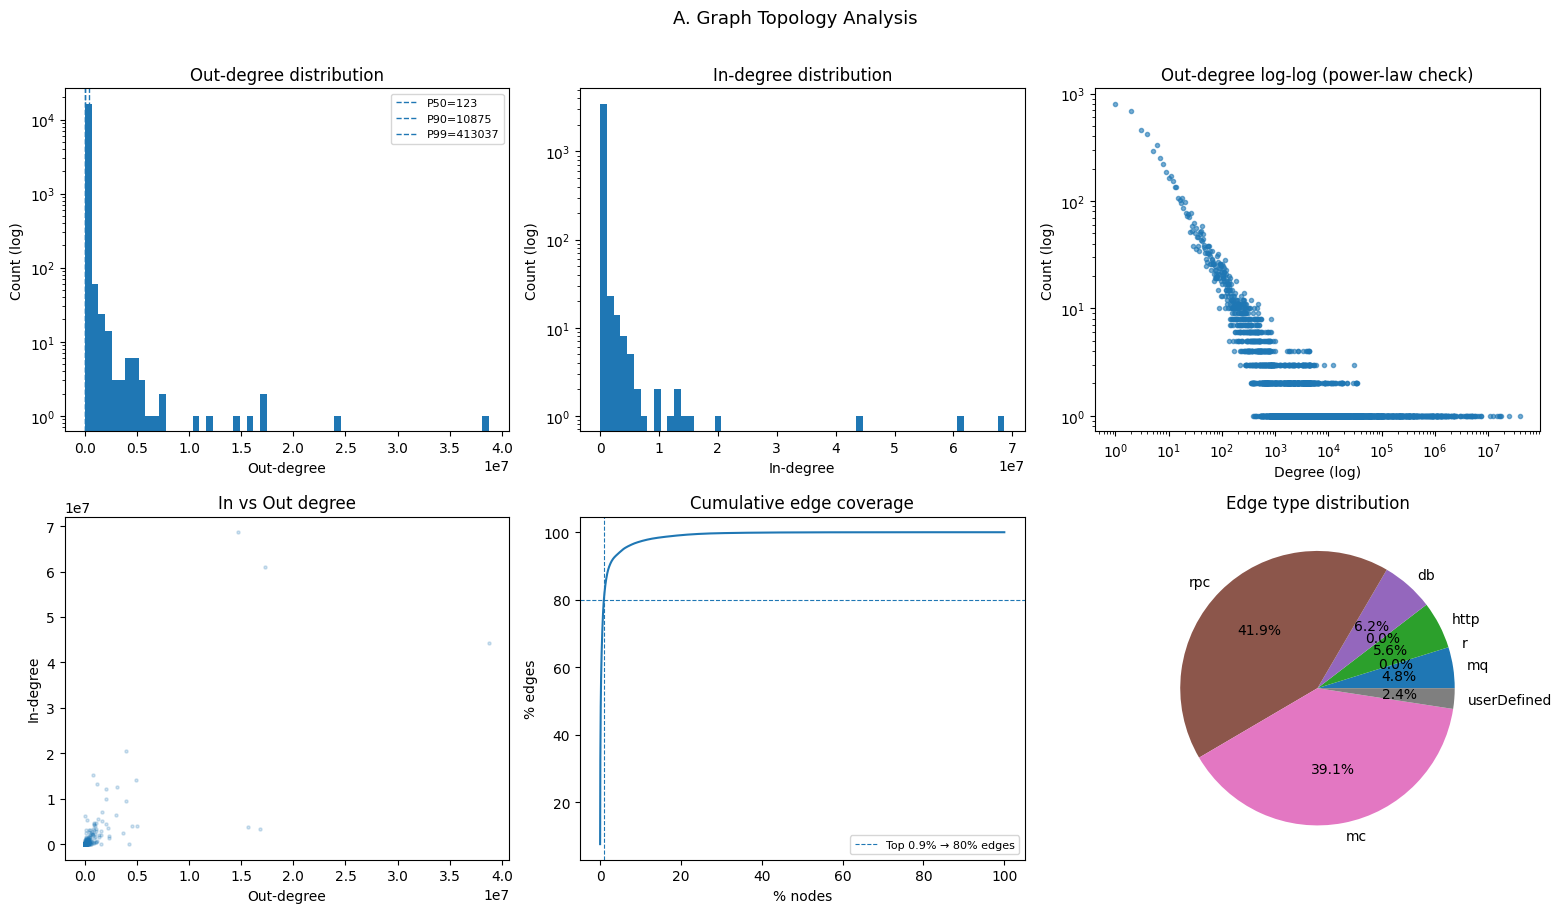

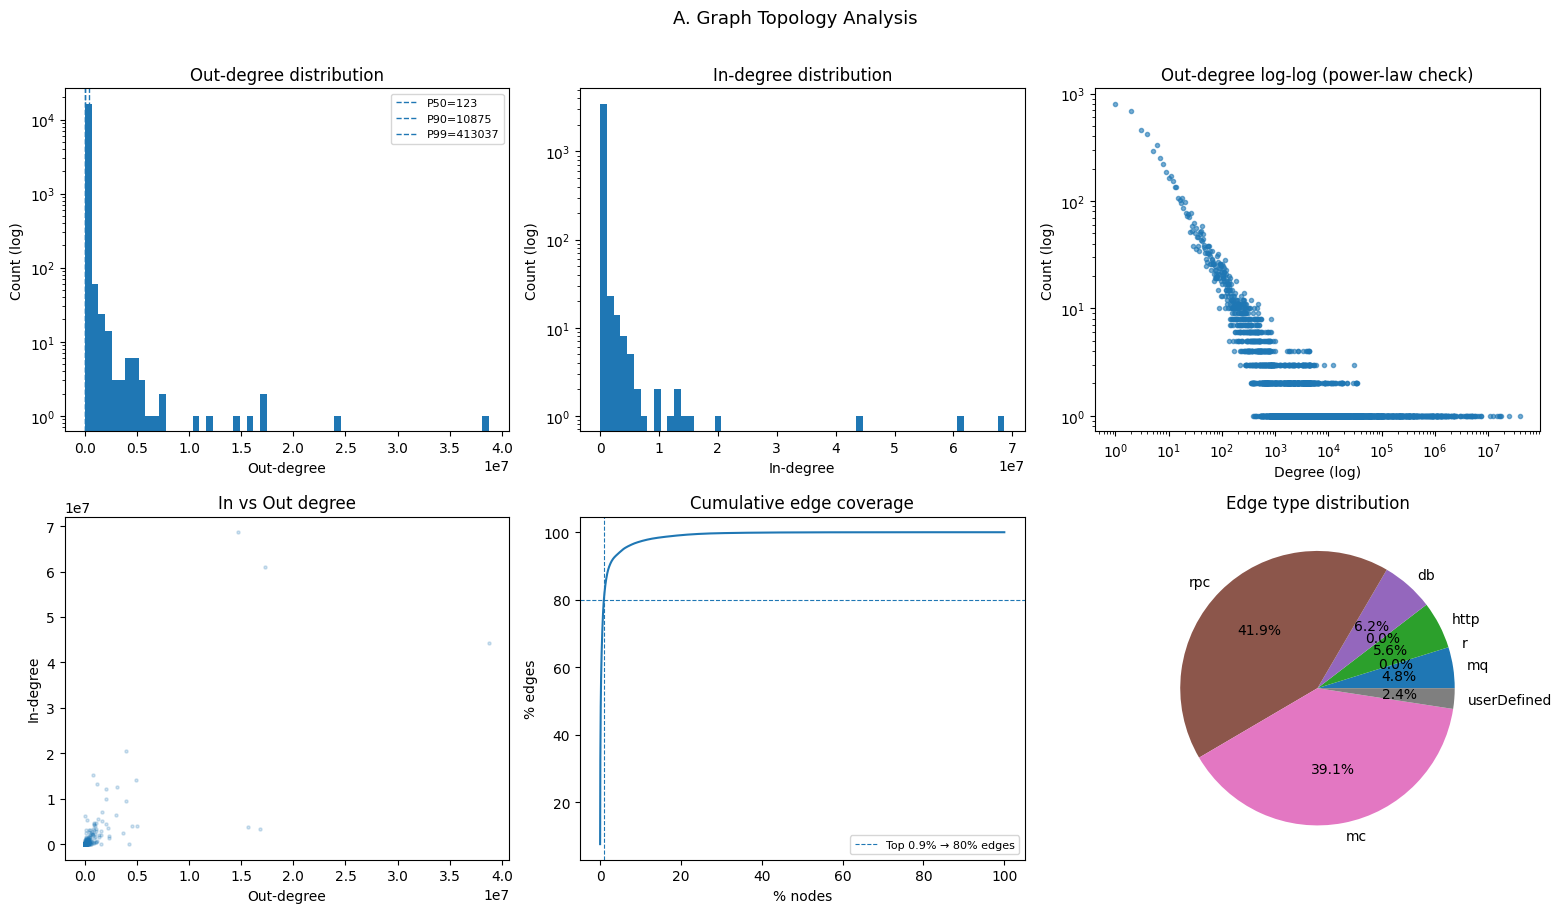

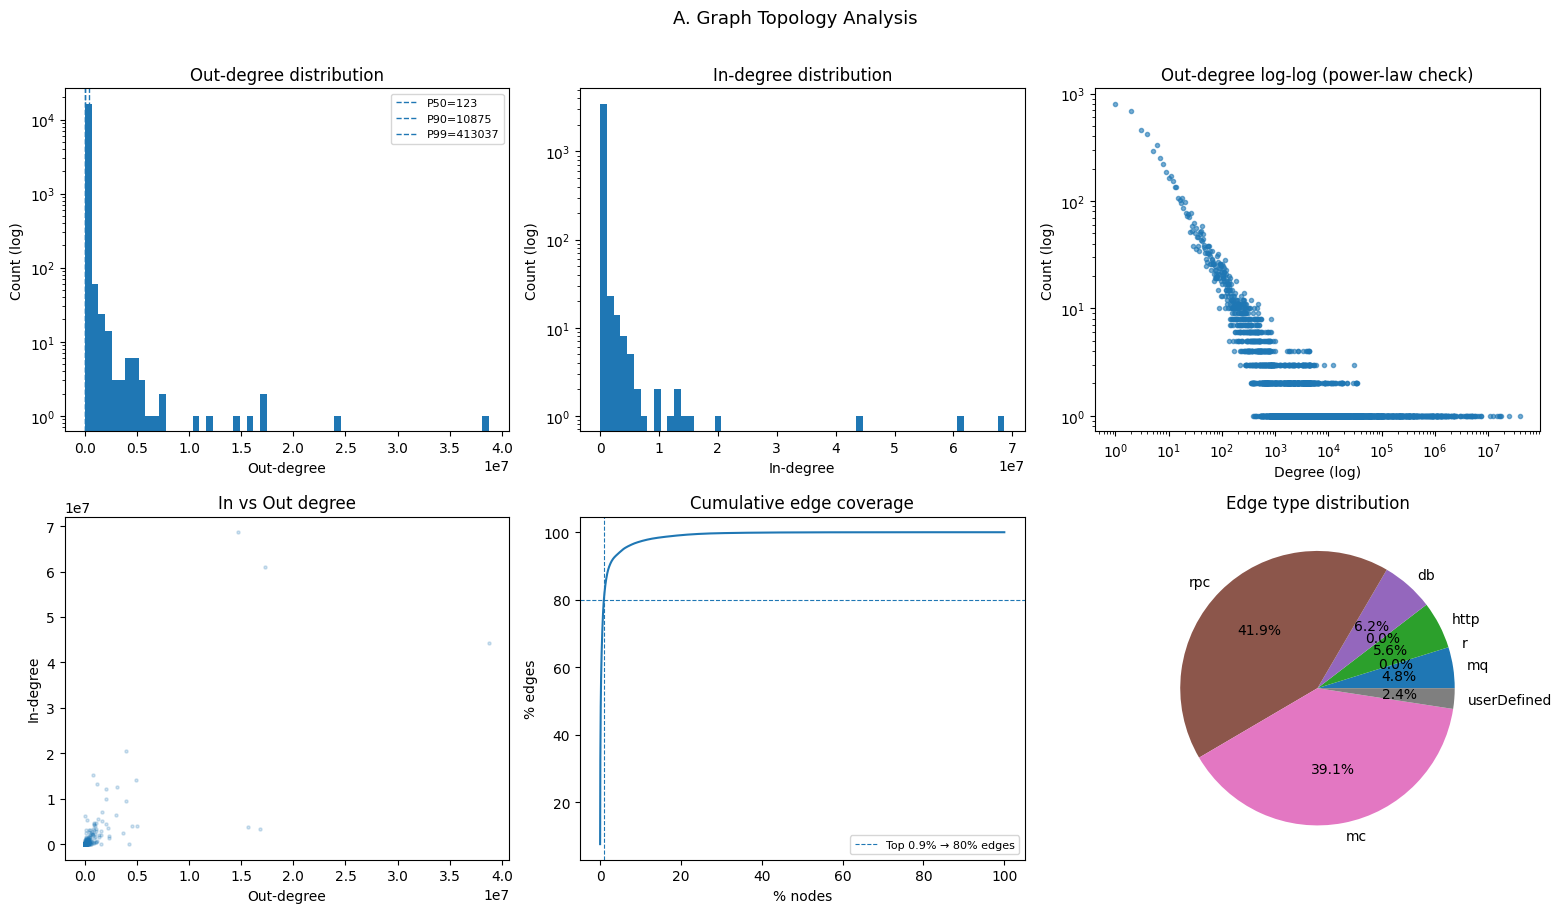

In [10]:
print("\n" + "="*60)
print("A2 — Graph Topology Visualization (SHOW ONLY)")
print("="*60)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── Convert aggregated Spark results → pandas ────────────────
out_pd = out_deg.toPandas()
in_pd  = in_deg.toPandas()

# ── Figure layout ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── (1) Out-degree histogram ─────────────────────────────────
ax = axes[0,0]
ax.hist(out_pd["out_degree"], bins=60, log=True)
ax.set_title("Out-degree distribution")
ax.set_xlabel("Out-degree"); ax.set_ylabel("Count (log)")

for q,l in [(0.5,"P50"),(0.9,"P90"),(0.99,"P99")]:
    v = out_pd["out_degree"].quantile(q)
    ax.axvline(v, linestyle="--", linewidth=1, label=f"{l}={v:.0f}")
ax.legend(fontsize=8)

# ── (2) In-degree histogram ──────────────────────────────────
ax = axes[0,1]
ax.hist(in_pd["in_degree"], bins=60, log=True)
ax.set_title("In-degree distribution")
ax.set_xlabel("In-degree"); ax.set_ylabel("Count (log)")

# ── (3) Log-log (power-law check) ────────────────────────────
ax = axes[0,2]
dc = out_pd["out_degree"].value_counts().sort_index()
ax.loglog(dc.index, dc.values, "o", ms=3, alpha=0.6)
ax.set_title("Out-degree log-log (power-law check)")
ax.set_xlabel("Degree (log)"); ax.set_ylabel("Count (log)")

# ── (4) In vs Out scatter ────────────────────────────────────
merged = out_pd.rename(columns={"DM":"svc"}) \
    .merge(in_pd.rename(columns={"UM":"svc"}), on="svc", how="inner")

ax = axes[1,0]
s = merged.sample(min(5000, len(merged)), random_state=0)
ax.scatter(s["out_degree"], s["in_degree"], alpha=0.2, s=5)
ax.set_xlabel("Out-degree"); ax.set_ylabel("In-degree")
ax.set_title("In vs Out degree")

# ── (5) Cumulative edge coverage ─────────────────────────────
ax = axes[1,1]
sv = np.sort(out_pd["out_degree"].values)[::-1]
cs = np.cumsum(sv) / sv.sum() * 100
pn = np.arange(1, len(sv)+1) / len(sv) * 100

ax.plot(pn, cs, linewidth=1.5)
ax.axhline(80, linestyle="--", linewidth=0.8)

i80 = np.searchsorted(cs, 80)
p80 = pn[min(i80, len(pn)-1)]
ax.axvline(p80, linestyle="--", linewidth=0.8,
           label=f"Top {p80:.1f}% → 80% edges")

ax.set_xlabel("% nodes"); ax.set_ylabel("% edges")
ax.set_title("Cumulative edge coverage")
ax.legend(fontsize=8)

# ── (6) RPC type distribution ────────────────────────────────
ax = axes[1,2]
rpc_pd = cg.groupBy("rpctype").count().toPandas()
ax.pie(rpc_pd["count"], labels=rpc_pd["rpctype"], autopct="%1.1f%%")
ax.set_title("Edge type distribution")

# ── Display ──────────────────────────────────────────────────
plt.suptitle("A. Graph Topology Analysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### In-degree vs Out-degree plot → “Who is important?”

Think of each service like a person:

Out-degree = how many others it calls
In-degree = how many call it

Types of services:

Super-connectors (high in + high out)
Talk to many services AND are called by many

These are the core bottlenecks
If slow → everything becomes slow
Sources (high out, low in)

They call many services (like API gateways)
They are starting points of requests
Sinks (high in, low out)

They receive lots of requests (like databases or aggregators)


### log-log plot

X-axis: how connected a service is
Y-axis: how many services have that connectivity
Log-log plot: compresses huge differences so patterns become visible


### TEMPORAL PATTERNS

In [36]:
# B1 — Global resource time series
print("  Computing global resource time series ...")
global_ts = (load_resource()
    .coalesce(16)                    # keep partition count low
    .groupBy("t_idx")
    .agg(
        F.mean("cpu_utilization").alias("cpu_mean"),
        F.stddev("cpu_utilization").alias("cpu_std"),
        F.mean("memory_utilization").alias("mem_mean"),
        F.stddev("memory_utilization").alias("mem_std"),
        F.percentile_approx("cpu_utilization",  0.95).alias("cpu_p95"),
        F.percentile_approx("memory_utilization",0.95).alias("mem_p95"),
        F.countDistinct("msname").alias("n_services"),
    )
    .orderBy("t_idx")
    .toPandas())
 
print(f"  Timesteps: {len(global_ts)}")
print(f"  Global mean CPU    : {global_ts['cpu_mean'].mean():.4f}")
print(f"  Global mean Memory : {global_ts['mem_mean'].mean():.4f}")

  Computing global resource time series ...


[Stage 12:====================================================>   (15 + 1) / 16]

  Timesteps: 1440
  Global mean CPU    : 0.1886
  Global mean Memory : 0.6560


In [37]:
# B2 — Traffic time series
print("  Computing traffic time series ...")
avail_traffic = [c for c in TRAFFIC_COLS
                 if c in load_rtqps().columns]
global_traffic = (load_rtqps()
    .coalesce(16)
    .groupBy("t_idx")
    .agg(*[F.mean(c).alias(c) for c in avail_traffic])
    .orderBy("t_idx")
    .toPandas())
 

  Computing traffic time series ...


In [38]:
# # B3 — Plot global time series
# fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
# t_min = global_ts["t_idx"] * 30 / 60
 
# ax = axes[0,0]
# ax.plot(t_min, global_ts["cpu_mean"], color="#7F77DD", lw=0.8, label="mean")
# ax.fill_between(t_min,
#     global_ts["cpu_mean"] - global_ts["cpu_std"],
#     global_ts["cpu_mean"] + global_ts["cpu_std"],
#     alpha=0.2, color="#7F77DD", label="±1σ")
# ax.plot(t_min, global_ts["cpu_p95"], color="#D85A30",
#         lw=0.6, ls="--", label="P95")
# ax.set_title("CPU utilization over time")
# ax.set_ylabel("CPU util"); ax.legend(fontsize=8)
 
# ax = axes[0,1]
# ax.plot(t_min, global_ts["mem_mean"], color="#1D9E75", lw=0.8, label="mean")
# ax.fill_between(t_min,
#     global_ts["mem_mean"] - global_ts["mem_std"],
#     global_ts["mem_mean"] + global_ts["mem_std"],
#     alpha=0.2, color="#1D9E75")
# ax.plot(t_min, global_ts["mem_p95"], color="#D85A30",
#         lw=0.6, ls="--", label="P95")
# ax.set_title("Memory utilization over time")
# ax.set_ylabel("Memory util"); ax.legend(fontsize=8)
 
# ax = axes[1,0]
# ax.plot(t_min, global_ts["n_services"], color="#EF9F27", lw=0.8)
# ax.set_title("Active services per timestep")
# ax.set_ylabel("# services")
 
# if len(global_traffic) > 0:
#     t2 = global_traffic["t_idx"] * 30 / 60
#     ax = axes[1,1]
#     for col, color, label in [
#         ("providerRPC_MCR","#7F77DD","RPC MCR"),
#         ("HTTP_MCR",        "#D85A30","HTTP MCR"),
#         ("consumerMQ_MCR",  "#1D9E75","MQ MCR"),
#     ]:
#         if col in global_traffic.columns:
#             ax.plot(t2, global_traffic[col], color=color,
#                     lw=0.8, label=label)
#     ax.set_title("Mean call rates over time")
#     ax.set_ylabel("MCR"); ax.legend(fontsize=8)
 
#     ax = axes[2,0]
#     if "providerRPC_RT" in global_traffic.columns:
#         ax.plot(t2, global_traffic["providerRPC_RT"],
#                 color="#534AB7", lw=0.8)
#     ax.set_title("Mean RPC response time")
#     ax.set_ylabel("RT")
 
# ax = axes[2,1]
# ax.plot(t_min, global_ts["cpu_std"], color="#D85A30", lw=0.8)
# ax.set_title("CPU volatility (std over time)")
# ax.set_ylabel("CPU std")
 
# for ax in axes.flat:
#     ax.set_xlabel("Time (minutes)")
 
# plt.suptitle("B. Global Temporal Patterns — 12 Hours", fontsize=13)
# plt.tight_layout()
# plt.savefig(f"{OUT_DIR}/B1_temporal_patterns.png", dpi=150)
# plt.close()
# print(f"✓ Saved: {OUT_DIR}/B1_temporal_patterns.png")

✓ Saved: eda_advanced/B1_temporal_patterns.png


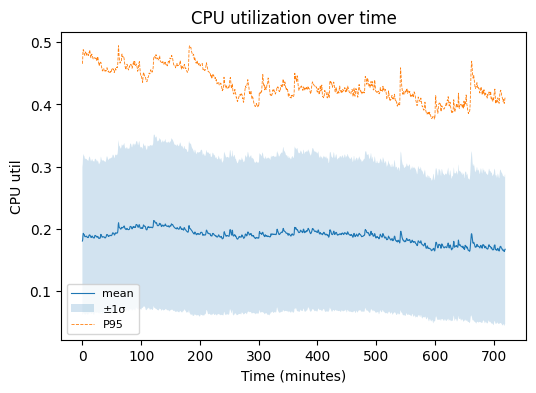

In [39]:
import matplotlib.pyplot as plt

t_min = global_ts["t_idx"] * 30 / 60

# -----------------------------
# 1. CPU utilization
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(t_min, global_ts["cpu_mean"], lw=0.8, label="mean")
plt.fill_between(t_min,
    global_ts["cpu_mean"] - global_ts["cpu_std"],
    global_ts["cpu_mean"] + global_ts["cpu_std"],
    alpha=0.2, label="±1σ")
plt.plot(t_min, global_ts["cpu_p95"],
         lw=0.6, ls="--", label="P95")

plt.title("CPU utilization over time")
plt.xlabel("Time (minutes)")
plt.ylabel("CPU util")
plt.legend(fontsize=8)
plt.show()



This tells you:

The system is NOT limited by CPU
The system is limited by MEMORY

So adding more CPU won’t help much

#### CPU is NOT the problem
There is plenty of CPU available.

#### Memory is the bottleneck
Memory is much more heavily used.

#### System is stable
No extreme fluctuations → predictable workload

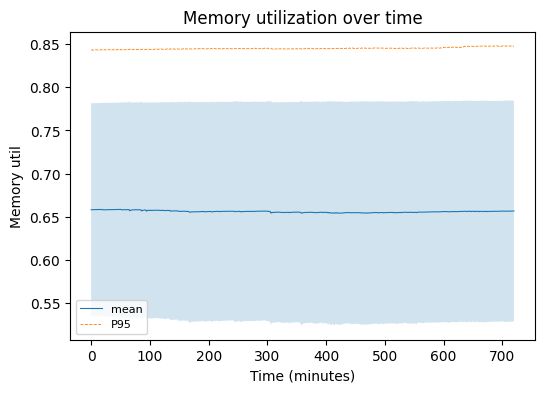

In [40]:
# -----------------------------
# 2. Memory utilization
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(t_min, global_ts["mem_mean"], lw=0.8, label="mean")
plt.fill_between(t_min,
    global_ts["mem_mean"] - global_ts["mem_std"],
    global_ts["mem_mean"] + global_ts["mem_std"],
    alpha=0.2)
plt.plot(t_min, global_ts["mem_p95"],
         lw=0.6, ls="--", label="P95")

plt.title("Memory utilization over time")
plt.xlabel("Time (minutes)")
plt.ylabel("Memory util")
plt.legend(fontsize=8)
plt.show()

### High baseline memory (65%)
Even when system is “quiet”, memory is still high.
Even doing nothing, each service still consumes memory.

### No spikes / flat line
Memory doesn’t go up and down much.
Memory usage is predictable and stable


memory usage is mostly constant and high because each microservice keeps memory reserved permanently, making memory the real limiting resource—not CPU.

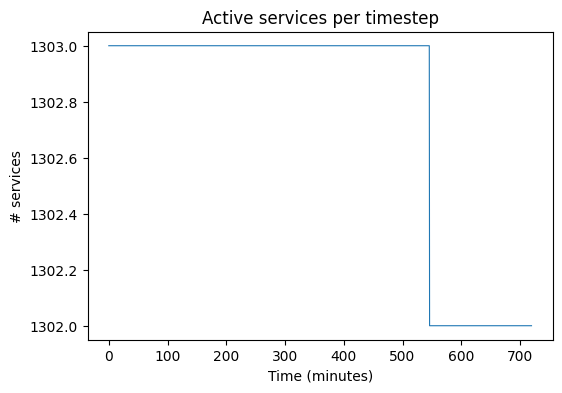

In [41]:
# -----------------------------
# 3. Active services
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(t_min, global_ts["n_services"], lw=0.8)

plt.title("Active services per timestep")
plt.xlabel("Time (minutes)")
plt.ylabel("# services")
plt.show()

Total services in dataset: ~16,000
Active at a time: ~1,300

a straight line… with one tiny drop
Most services are NOT active at the same time


System is stable
Services don’t frequently start/stop


Your system runs a fixed set of services with almost no changes over time, and only a small fraction of all services are active at once—making it stable, predictable, and potentially inefficient.

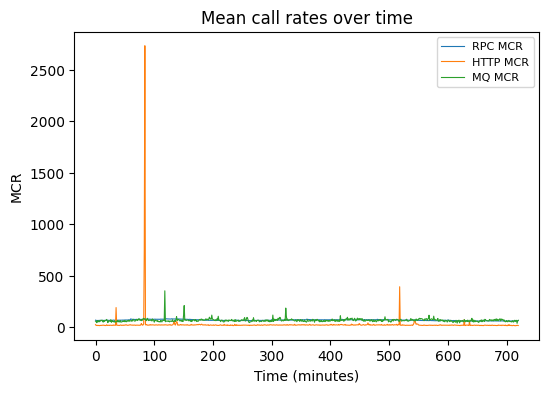

In [42]:
# -----------------------------
# 4. Mean call rates (if exists)
# -----------------------------
if len(global_traffic) > 0:
    t2 = global_traffic["t_idx"] * 30 / 60

    plt.figure(figsize=(6,4))
    for col, label in [
        ("providerRPC_MCR","RPC MCR"),
        ("HTTP_MCR","HTTP MCR"),
        ("consumerMQ_MCR","MQ MCR"),
    ]:
        if col in global_traffic.columns:
            plt.plot(t2, global_traffic[col], lw=0.8, label=label)

    plt.title("Mean call rates over time")
    plt.xlabel("Time (minutes)")
    plt.ylabel("MCR")
    plt.legend(fontsize=8)
    plt.show()

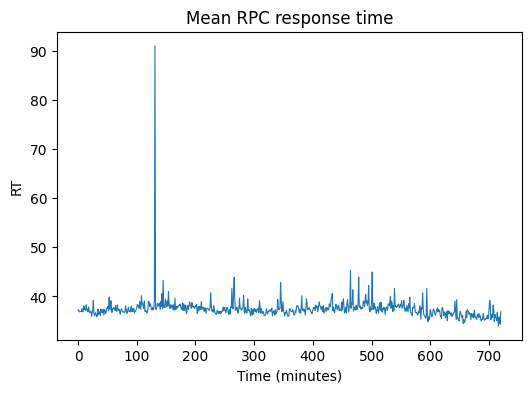

In [43]:
# -----------------------------
# 5. RPC response time
# -----------------------------
if len(global_traffic) > 0 and "providerRPC_RT" in global_traffic.columns:
    plt.figure(figsize=(6,4))
    plt.plot(t2, global_traffic["providerRPC_RT"], lw=0.8)

    plt.title("Mean RPC response time")
    plt.xlabel("Time (minutes)")
    plt.ylabel("RT")
    plt.show()

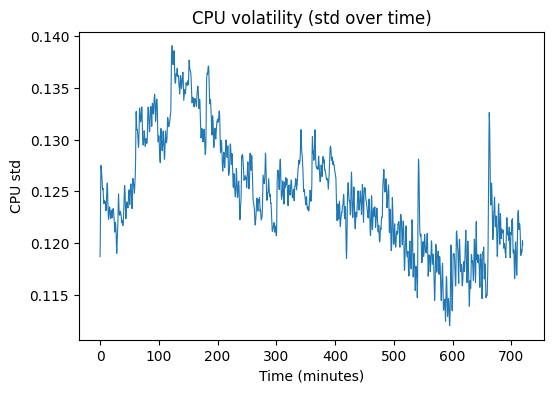

In [44]:
# -----------------------------
# 6. CPU volatility
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(t_min, global_ts["cpu_std"], lw=0.8)

plt.title("CPU volatility (std over time)")
plt.xlabel("Time (minutes)")
plt.ylabel("CPU std")
plt.show()

In [45]:
# # B4 — Autocorrelation (GRU window size)
# print("\n  Computing autocorrelations ...")
 
# # Find fully-present services
# full_svcs = (load_resource()
#     .coalesce(16)
#     .groupBy("msname")
#     .agg(F.countDistinct("t_idx").alias("n_steps"))
#     .filter(F.col("n_steps") >= 1400)
#     .limit(30)
#     .select("msname")
#     .toPandas()["msname"].tolist())
 
# print(f"  Services with ≥1400 timesteps: {len(full_svcs)}")
 
# if full_svcs:
#     ts_data = (load_resource()
#         .filter(F.col("msname").isin(full_svcs))
#         .coalesce(16)
#         .groupBy("msname","t_idx")
#         .agg(F.mean("cpu_utilization").alias("cpu"),
#              F.mean("memory_utilization").alias("mem"))
#         .orderBy("msname","t_idx")
#         .toPandas())
 
#     max_lag = 72
#     acf_cpu, acf_mem = [], []
#     for svc in full_svcs:
#         svc_ts = (ts_data[ts_data["msname"]==svc]
#                   .set_index("t_idx")
#                   .reindex(range(1440))
#                   .fillna(method="ffill")
#                   .fillna(method="bfill"))
#         if len(svc_ts) < max_lag + 5: continue
#         acf_cpu.append([svc_ts["cpu"].autocorr(l) for l in range(1,max_lag+1)])
#         acf_mem.append([svc_ts["mem"].autocorr(l) for l in range(1,max_lag+1)])
 
#     acf_cpu_m = np.nanmean(acf_cpu, axis=0)
#     acf_mem_m = np.nanmean(acf_mem, axis=0)
#     lags      = np.arange(1, max_lag+1)
#     conf      = 1.96 / np.sqrt(1440)
 
#     fig, axes = plt.subplots(1, 2, figsize=(14, 4))
#     rec_window = 12   # default fallback
#     for ax, acf, label, color in [
#         (axes[0], acf_cpu_m, "CPU",    "#7F77DD"),
#         (axes[1], acf_mem_m, "Memory", "#1D9E75"),
#     ]:
#         ax.bar(lags*30, acf, width=25, color=color, alpha=0.7)
#         ax.axhline( conf, color="#D85A30", ls="--", lw=1, label="95% CI")
#         ax.axhline(-conf, color="#D85A30", ls="--", lw=1)
#         ax.axhline(0, color="black", lw=0.4)
#         ax.set_xlabel("Lag (seconds)")
#         ax.set_ylabel("Autocorrelation")
#         ax.set_title(f"{label} autocorrelation")
#         sig = [l*30 for l,v in zip(lags,acf) if abs(v) > conf]
#         if sig:
#             rec_window = max(sig) // 30
#             ax.axvline(max(sig), color="#EF9F27", ls=":", lw=1.5,
#                        label=f"Last sig: {max(sig)}s = {rec_window} steps")
#         ax.legend(fontsize=8)
 
#     plt.suptitle("B2. Autocorrelation → GRU window size", fontsize=12)
#     plt.tight_layout()
#     plt.savefig(f"{OUT_DIR}/B2_autocorrelation.png", dpi=150)
#     plt.close()
#     print(f"✓ Saved: {OUT_DIR}/B2_autocorrelation.png")
#     print(f"  Recommended GRU window: {rec_window} steps "
#           f"({rec_window*30}s = {rec_window*30//60} min)")
 


  Computing autocorrelations ...


  Services with ≥1400 timesteps: 30


✓ Saved: eda_advanced/B2_autocorrelation.png
  Recommended GRU window: 72 steps (2160s = 36 min)


In [46]:
import matplotlib.pyplot as plt
import numpy as np

print("\n  Computing autocorrelations ...")

# --- Find fully-present services ---
full_svcs = (load_resource()
    .coalesce(16)
    .groupBy("msname")
    .agg(F.countDistinct("t_idx").alias("n_steps"))
    .filter(F.col("n_steps") >= 1400)
    .limit(30)
    .select("msname")
    .toPandas()["msname"].tolist())

print(f"  Services with ≥1400 timesteps: {len(full_svcs)}")

if full_svcs:
    ts_data = (load_resource()
        .filter(F.col("msname").isin(full_svcs))
        .coalesce(16)
        .groupBy("msname","t_idx")
        .agg(F.mean("cpu_utilization").alias("cpu"),
             F.mean("memory_utilization").alias("mem"))
        .orderBy("msname","t_idx")
        .toPandas())

    max_lag = 72
    acf_cpu, acf_mem = [], []

    for svc in full_svcs:
        svc_ts = (ts_data[ts_data["msname"]==svc]
                  .set_index("t_idx")
                  .reindex(range(1440))
                  .fillna(method="ffill")
                  .fillna(method="bfill"))

        if len(svc_ts) < max_lag + 5:
            continue

        acf_cpu.append([svc_ts["cpu"].autocorr(l) for l in range(1, max_lag+1)])
        acf_mem.append([svc_ts["mem"].autocorr(l) for l in range(1, max_lag+1)])

    acf_cpu_m = np.nanmean(acf_cpu, axis=0)
    acf_mem_m = np.nanmean(acf_mem, axis=0)
    lags = np.arange(1, max_lag+1)
    conf = 1.96 / np.sqrt(1440)

    rec_window = 12  # fallback



  Computing autocorrelations ...


  Services with ≥1400 timesteps: 30


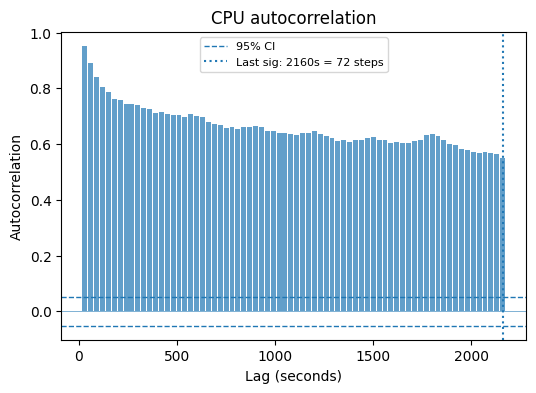

In [ ]:
    # -----------------------------
    # 1. CPU autocorrelation
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(lags*30, acf_cpu_m, width=25, alpha=0.7)

plt.axhline(conf, ls="--", lw=1, label="95% CI")
plt.axhline(-conf, ls="--", lw=1)
plt.axhline(0, lw=0.4)

sig = [l*30 for l,v in zip(lags, acf_cpu_m) if abs(v) > conf]
if sig:
    rec_window = max(sig) // 30
    plt.axvline(max(sig), ls=":", lw=1.5,
                label=f"Last sig: {max(sig)}s = {rec_window} steps")

plt.title("CPU autocorrelation")
plt.xlabel("Lag (seconds)")
plt.ylabel("Autocorrelation")
plt.legend(fontsize=8)
plt.show()


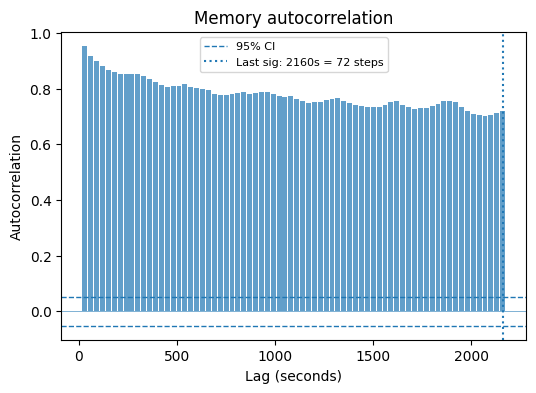

  Recommended GRU window: 72 steps (2160s = 36 min)


In [48]:
    # -----------------------------
    # 2. Memory autocorrelation
    # -----------------------------
    plt.figure(figsize=(6,4))
    plt.bar(lags*30, acf_mem_m, width=25, alpha=0.7)

    plt.axhline(conf, ls="--", lw=1, label="95% CI")
    plt.axhline(-conf, ls="--", lw=1)
    plt.axhline(0, lw=0.4)

    sig = [l*30 for l,v in zip(lags, acf_mem_m) if abs(v) > conf]
    if sig:
        rec_window = max(sig) // 30
        plt.axvline(max(sig), ls=":", lw=1.5,
                    label=f"Last sig: {max(sig)}s = {rec_window} steps")

    plt.title("Memory autocorrelation")
    plt.xlabel("Lag (seconds)")
    plt.ylabel("Autocorrelation")
    plt.legend(fontsize=8)
    plt.show()

    print(f"  Recommended GRU window: {rec_window} steps "
          f"({rec_window*30}s = {rec_window*30//60} min)")

In [49]:
# # B5 — FFT periodicity
# if full_svcs and len(ts_data) > 0:
#     svc = full_svcs[0]
#     cpu_s = (ts_data[ts_data["msname"]==svc]
#              .set_index("t_idx")["cpu"]
#              .reindex(range(1440))
#              .fillna(method="ffill").values)
 
#     fft_v   = np.abs(np.fft.rfft(cpu_s - np.nanmean(cpu_s)))
#     freqs   = np.fft.rfftfreq(len(cpu_s), d=30)
#     periods = np.where(freqs > 0, 1/freqs, 0)
 
#     fig, ax = plt.subplots(figsize=(12, 4))
#     mask = (periods > 0) & (periods < 3600)
#     ax.plot(periods[mask]/60, fft_v[mask], color="#7F77DD", lw=0.8)
#     ax.set_xlabel("Period (minutes)")
#     ax.set_ylabel("FFT amplitude")
#     ax.set_title("B3. Frequency spectrum — periodic patterns in CPU")
#     top5 = np.argsort(fft_v[mask])[-5:]
#     p_plot = periods[mask]
#     v_plot = fft_v[mask]
#     for i in top5:
#         ax.axvline(p_plot[i]/60, color="#D85A30", ls="--",
#                    lw=0.8, alpha=0.7)
#         ax.text(p_plot[i]/60, v_plot[i],
#                 f" {p_plot[i]/60:.1f}m", fontsize=8, color="#D85A30")
#     plt.tight_layout()
#     plt.savefig(f"{OUT_DIR}/B3_fft_periodicity.png", dpi=150)
#     plt.close()
#     print(f"✓ Saved: {OUT_DIR}/B3_fft_periodicity.png")
 

✓ Saved: eda_advanced/B3_fft_periodicity.png


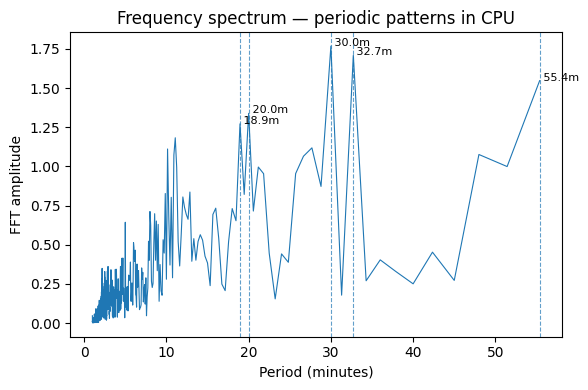

In [50]:
# B5 — FFT periodicity (display only)

if full_svcs and len(ts_data) > 0:
    svc = full_svcs[0]

    cpu_s = (ts_data[ts_data["msname"]==svc]
             .set_index("t_idx")["cpu"]
             .reindex(range(1440))
             .fillna(method="ffill")
             .values)

    fft_v   = np.abs(np.fft.rfft(cpu_s - np.nanmean(cpu_s)))
    freqs   = np.fft.rfftfreq(len(cpu_s), d=30)
    periods = np.where(freqs > 0, 1/freqs, 0)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(6,4))

    mask = (periods > 0) & (periods < 3600)

    plt.plot(periods[mask]/60, fft_v[mask], lw=0.8)

    # Top 5 peaks
    top5 = np.argsort(fft_v[mask])[-5:]
    p_plot = periods[mask]
    v_plot = fft_v[mask]

    for i in top5:
        plt.axvline(p_plot[i]/60, ls="--", lw=0.8, alpha=0.7)
        plt.text(p_plot[i]/60, v_plot[i],
                 f" {p_plot[i]/60:.1f}m", fontsize=8)

    plt.xlabel("Period (minutes)")
    plt.ylabel("FFT amplitude")
    plt.title("Frequency spectrum — periodic patterns in CPU")

    plt.tight_layout()
    plt.show()

In [52]:
# #C. CROSS-TABLE CORRELATION
# # ════════════════════════════════════════════════════════════════
# print("\n" + "="*60)
# print("C. CROSS-TABLE CORRELATION")
# print("="*60)
 
# res_agg = (load_resource()
#     .coalesce(16)
#     .groupBy("msname","t_idx")
#     .agg(F.mean("cpu_utilization").alias("cpu"),
#          F.mean("memory_utilization").alias("mem")))
 
# rtqps_avail = [c for c in TRAFFIC_COLS
#                if c in load_rtqps().columns]
# rtqps_df = (load_rtqps()
#     .coalesce(16)
#     .select("msname","t_idx",*rtqps_avail))
 
# joined = res_agg.join(rtqps_df, on=["msname","t_idx"], how="inner")
# n_joined = joined.count()
# print(f"  Joined rows: {n_joined:,}")
 
# SAMPLE_N  = min(100_000, n_joined)
# sample_frac = SAMPLE_N / n_joined
# corr_pd = joined.sample(False, sample_frac, seed=42).toPandas()
 
# corr_cols   = ["cpu","mem"] + rtqps_avail
# corr_matrix = corr_pd[corr_cols].corr()
 
# print("\nCorrelation with cpu_utilization:")
# print(corr_matrix["cpu"].sort_values(ascending=False).round(3).to_string())
# print("\nCorrelation with memory_utilization:")
# print(corr_matrix["mem"].sort_values(ascending=False).round(3).to_string())
 
# fig, ax = plt.subplots(figsize=(10, 8))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="PuOr",
#             center=0, linewidths=0.5, ax=ax, mask=mask,
#             annot_kws={"size":9})
# ax.set_title("C. Feature correlation matrix\n"
#              "(resource × traffic — joined on msname × t_idx)")
# plt.tight_layout()
# plt.savefig(f"{OUT_DIR}/C_correlation_matrix.png", dpi=150)
# plt.close()
# print(f"✓ Saved: {OUT_DIR}/C_correlation_matrix.png")


C. CROSS-TABLE CORRELATION


  Joined rows: 935,234



Correlation with cpu_utilization:
cpu                1.000
consumerRPC_MCR    0.483
providerRPC_MCR    0.409
mem                0.328
HTTP_MCR           0.004
HTTP_RT            0.004
consumerRPC_RT    -0.004
consumerMQ_MCR    -0.006
consumerMQ_RT     -0.006
providerRPC_RT    -0.043

Correlation with memory_utilization:
mem                1.000
cpu                0.328
consumerRPC_MCR    0.140
providerRPC_MCR    0.042
consumerMQ_MCR     0.019
consumerMQ_RT      0.019
consumerRPC_RT    -0.010
HTTP_MCR          -0.023
HTTP_RT           -0.023
providerRPC_RT    -0.049
✓ Saved: eda_advanced/C_correlation_matrix.png


In [53]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("\n" + "="*60)
print("C. CROSS-TABLE CORRELATION")
print("="*60)

res_agg = (load_resource()
    .coalesce(16)
    .groupBy("msname","t_idx")
    .agg(F.mean("cpu_utilization").alias("cpu"),
         F.mean("memory_utilization").alias("mem")))

rtqps_avail = [c for c in TRAFFIC_COLS
               if c in load_rtqps().columns]

rtqps_df = (load_rtqps()
    .coalesce(16)
    .select("msname","t_idx", *rtqps_avail))

joined = res_agg.join(rtqps_df, on=["msname","t_idx"], how="inner")

n_joined = joined.count()
print(f"  Joined rows: {n_joined:,}")


C. CROSS-TABLE CORRELATION


[Stage 106:============================>                           (8 + 8) / 16]

  Joined rows: 935,234


In [54]:
# -----------------------------
# Sampling (important for memory)
# -----------------------------
SAMPLE_N = min(100_000, n_joined)
sample_frac = SAMPLE_N / n_joined

corr_pd = joined.sample(False, sample_frac, seed=42).toPandas()

corr_cols = ["cpu","mem"] + rtqps_avail
corr_matrix = corr_pd[corr_cols].corr()

print("\nCorrelation with cpu_utilization:")
print(corr_matrix["cpu"].sort_values(ascending=False).round(3).to_string())

print("\nCorrelation with memory_utilization:")
print(corr_matrix["mem"].sort_values(ascending=False).round(3).to_string())


Correlation with cpu_utilization:
cpu                1.000
consumerRPC_MCR    0.483
providerRPC_MCR    0.409
mem                0.328
HTTP_MCR           0.004
HTTP_RT            0.004
consumerRPC_RT    -0.004
consumerMQ_MCR    -0.006
consumerMQ_RT     -0.006
providerRPC_RT    -0.043

Correlation with memory_utilization:
mem                1.000
cpu                0.328
consumerRPC_MCR    0.140
providerRPC_MCR    0.042
consumerMQ_MCR     0.019
consumerMQ_RT      0.019
consumerRPC_RT    -0.010
HTTP_MCR          -0.023
HTTP_RT           -0.023
providerRPC_RT    -0.049


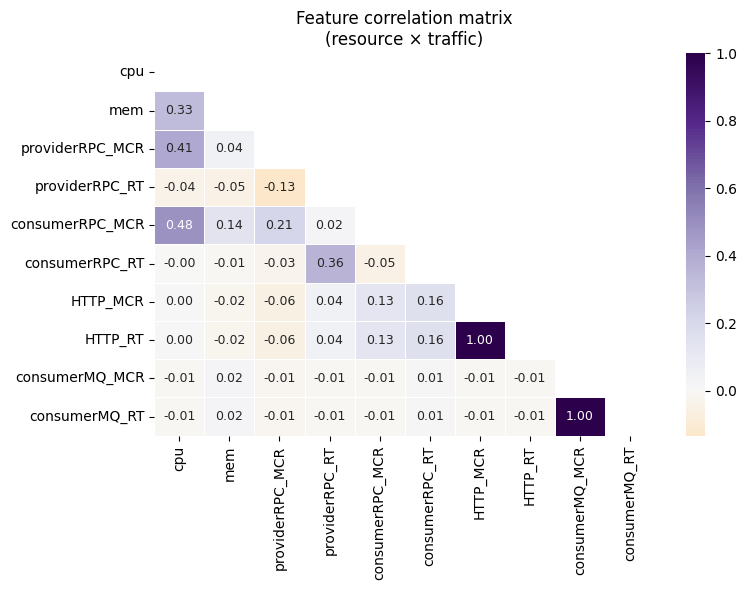

In [55]:
# -----------------------------
# Heatmap (display)
# -----------------------------
plt.figure(figsize=(8,6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="PuOr",
    center=0,
    linewidths=0.5,
    mask=mask,
    annot_kws={"size":9}
)

plt.title("Feature correlation matrix\n(resource × traffic)")
plt.tight_layout()
plt.show()

In [56]:
# # ════════════════════════════════════════════════════════════════
# # D. ANOMALY DETECTION
# # ════════════════════════════════════════════════════════════════
# print("\n" + "="*60)
# print("D. ANOMALY DETECTION")
# print("="*60)
 
# vol = (load_resource()
#     .coalesce(16)
#     .groupBy("msname")
#     .agg(
#         F.mean("cpu_utilization").alias("cpu_mean"),
#         F.stddev("cpu_utilization").alias("cpu_std"),
#         F.max("cpu_utilization").alias("cpu_max"),
#         F.mean("memory_utilization").alias("mem_mean"),
#         F.stddev("memory_utilization").alias("mem_std"),
#         F.max("memory_utilization").alias("mem_max"),
#         F.count("*").alias("n_records"),
#     )
#     .withColumn("cpu_cv",
#                 F.col("cpu_std") / (F.col("cpu_mean") + 1e-8))
#     .withColumn("spike_ratio",
#                 F.col("cpu_max") / (F.col("cpu_mean") + 1e-8))
#     .orderBy(F.desc("cpu_cv")))
 
# vol_pd = vol.toPandas()
# print(f"\nTop 10 most volatile services (CPU CV):")
# print(vol_pd.head(10)[["msname","cpu_mean","cpu_std",
#                         "cpu_cv","cpu_max"]].to_string(index=False))
 
# # Global spike timesteps
# cpu_global = (load_resource()
#     .coalesce(16)
#     .groupBy("t_idx")
#     .agg(F.mean("cpu_utilization").alias("cpu_mean"))
#     .orderBy("t_idx")
#     .toPandas())
# mu  = cpu_global["cpu_mean"].mean()
# sig = cpu_global["cpu_mean"].std()
# spikes = cpu_global[cpu_global["cpu_mean"] > mu + 3*sig]
# print(f"\nGlobal CPU spike timesteps (>μ+3σ={mu+3*sig:.4f}): "
#       f"{len(spikes)}")
 
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# ax = axes[0]
# ax.scatter(vol_pd["cpu_mean"], vol_pd["cpu_std"],
#            alpha=0.2, s=4, color="#7F77DD")
# ax.set_xlabel("CPU mean"); ax.set_ylabel("CPU std")
# ax.set_title("CPU mean vs std\n(top-right = high-load volatile)")
 
# ax = axes[1]
# ax.hist(vol_pd["cpu_cv"].dropna(), bins=60, color="#D85A30",
#         edgecolor="white", lw=0.3, log=True)
# ax.set_xlabel("CV (std/mean)"); ax.set_ylabel("Count (log)")
# ax.set_title("CPU volatility distribution")
# p95 = vol_pd["cpu_cv"].quantile(0.95)
# ax.axvline(p95, color="#EF9F27", ls="--", lw=1, label=f"P95={p95:.2f}")
# ax.legend(fontsize=8)
 
# ax = axes[2]
# ax.scatter(vol_pd["cpu_mean"], vol_pd["spike_ratio"],
#            alpha=0.2, s=4, color="#1D9E75")
# ax.set_xlabel("CPU mean"); ax.set_ylabel("Spike ratio (max/mean)")
# ax.set_title("Spike ratio vs mean load")
# ax.axhline(10, color="#D85A30", ls="--", lw=0.8, label="10× spike")
# ax.legend(fontsize=8)
 
# plt.suptitle("D. Anomaly Detection — Service Volatility", fontsize=12)
# plt.tight_layout()
# plt.savefig(f"{OUT_DIR}/D_anomaly_volatility.png", dpi=150)
# plt.close()
# print(f"✓ Saved: {OUT_DIR}/D_anomaly_volatility.png")


D. ANOMALY DETECTION



Top 10 most volatile services (CPU CV):
                                                          msname  cpu_mean  cpu_std   cpu_cv  cpu_max
dc334ccc515468986795752231adeea494726f9ce63460eb1662ee82d21de0a1  0.004871 0.008301 1.704355 0.136771
8229cf0afddf060bda27eb32d12db2635d74725140a5e920137a05e695008735  0.087780 0.117522 1.338831 1.080875
60d7cebdde6eca0597a5fa5bb0761de28180938553ab9c0a28205386cf527c5d  0.069031 0.091662 1.327829 0.660625
e845cc423a676d6789697de9ca283b123e4c846b0a3246067487be792a57f74b  0.042661 0.046257 1.084292 0.431375
7b56676eb8a95858f3eb5f8cda3bdda87ef0e903860507e110966bd228595f4b  0.115457 0.122505 1.061043 1.745254
2071f78e471c8f8d5d522f6fbc07e3f3ed532154bfaec6b7e276cc53d9d4b0a0  0.255788 0.269095 1.052022 0.892333
358e600f0761e77d74c586d61961fc53940fe654180cce128b50a08fc39c7278  0.193369 0.190315 0.984208 1.818833
9896bc5e7e7abf5854841d3861af961ceee47efc4b5b835d7067d19f8075b099  0.039772 0.037000 0.930285 0.618875
9d67b7482722bf75616474395c5b6a0497fd392ec


Global CPU spike timesteps (>μ+3σ=0.2210): 0
✓ Saved: eda_advanced/D_anomaly_volatility.png


In [57]:
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("D. ANOMALY DETECTION")
print("="*60)

vol = (load_resource()
    .coalesce(16)
    .groupBy("msname")
    .agg(
        F.mean("cpu_utilization").alias("cpu_mean"),
        F.stddev("cpu_utilization").alias("cpu_std"),
        F.max("cpu_utilization").alias("cpu_max"),
        F.mean("memory_utilization").alias("mem_mean"),
        F.stddev("memory_utilization").alias("mem_std"),
        F.max("memory_utilization").alias("mem_max"),
        F.count("*").alias("n_records"),
    )
    .withColumn("cpu_cv",
                F.col("cpu_std") / (F.col("cpu_mean") + 1e-8))
    .withColumn("spike_ratio",
                F.col("cpu_max") / (F.col("cpu_mean") + 1e-8))
    .orderBy(F.desc("cpu_cv")))

vol_pd = vol.toPandas()

print(f"\nTop 10 most volatile services (CPU CV):")
print(vol_pd.head(10)[["msname","cpu_mean","cpu_std",
                        "cpu_cv","cpu_max"]].to_string(index=False))


D. ANOMALY DETECTION


[Stage 135:===================================================>   (15 + 1) / 16]


Top 10 most volatile services (CPU CV):
                                                          msname  cpu_mean  cpu_std   cpu_cv  cpu_max
dc334ccc515468986795752231adeea494726f9ce63460eb1662ee82d21de0a1  0.004871 0.008301 1.704355 0.136771
8229cf0afddf060bda27eb32d12db2635d74725140a5e920137a05e695008735  0.087780 0.117522 1.338831 1.080875
60d7cebdde6eca0597a5fa5bb0761de28180938553ab9c0a28205386cf527c5d  0.069031 0.091662 1.327829 0.660625
e845cc423a676d6789697de9ca283b123e4c846b0a3246067487be792a57f74b  0.042661 0.046257 1.084292 0.431375
7b56676eb8a95858f3eb5f8cda3bdda87ef0e903860507e110966bd228595f4b  0.115457 0.122505 1.061043 1.745254
2071f78e471c8f8d5d522f6fbc07e3f3ed532154bfaec6b7e276cc53d9d4b0a0  0.255788 0.269095 1.052022 0.892333
358e600f0761e77d74c586d61961fc53940fe654180cce128b50a08fc39c7278  0.193369 0.190315 0.984208 1.818833
9896bc5e7e7abf5854841d3861af961ceee47efc4b5b835d7067d19f8075b099  0.039772 0.037000 0.930285 0.618875
9d67b7482722bf75616474395c5b6a0497fd392ec

In [58]:
# -----------------------------
# Global spike detection
# -----------------------------
cpu_global = (load_resource()
    .coalesce(16)
    .groupBy("t_idx")
    .agg(F.mean("cpu_utilization").alias("cpu_mean"))
    .orderBy("t_idx")
    .toPandas())

mu  = cpu_global["cpu_mean"].mean()
sig = cpu_global["cpu_mean"].std()

spikes = cpu_global[cpu_global["cpu_mean"] > mu + 3*sig]

print(f"\nGlobal CPU spike timesteps (>μ+3σ={mu+3*sig:.4f}): "
      f"{len(spikes)}")

[Stage 144:=========================================>             (12 + 4) / 16]


Global CPU spike timesteps (>μ+3σ=0.2210): 0


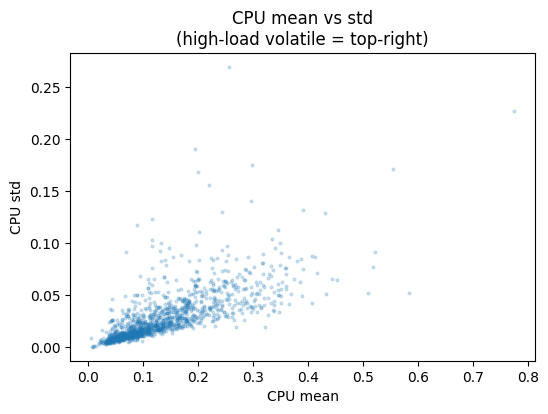

In [59]:
# -----------------------------
# 1. CPU mean vs std
# -----------------------------
plt.figure(figsize=(6,4))
plt.scatter(vol_pd["cpu_mean"], vol_pd["cpu_std"],
            alpha=0.2, s=4)

plt.xlabel("CPU mean")
plt.ylabel("CPU std")
plt.title("CPU mean vs std\n(high-load volatile = top-right)")
plt.show()

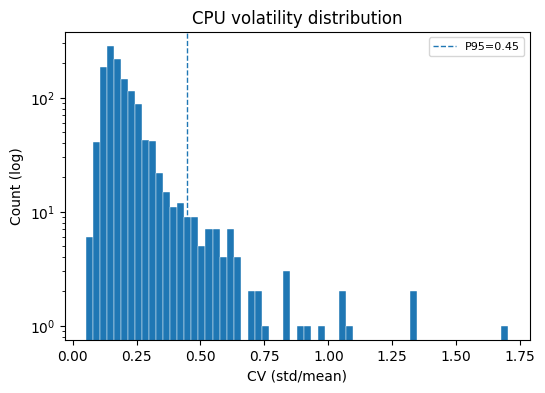

In [60]:
# -----------------------------
# 2. CPU CV distribution
# -----------------------------
plt.figure(figsize=(6,4))
plt.hist(vol_pd["cpu_cv"].dropna(), bins=60, log=True,
         edgecolor="white", lw=0.3)

p95 = vol_pd["cpu_cv"].quantile(0.95)

plt.axvline(p95, ls="--", lw=1,
            label=f"P95={p95:.2f}")

plt.xlabel("CV (std/mean)")
plt.ylabel("Count (log)")
plt.title("CPU volatility distribution")
plt.legend(fontsize=8)
plt.show()

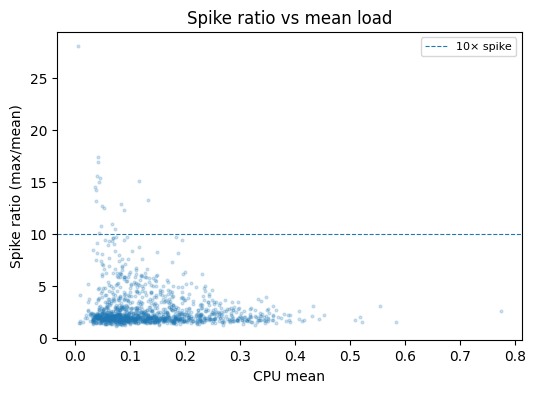

In [61]:

# -----------------------------
# 3. Spike ratio vs mean
# -----------------------------
plt.figure(figsize=(6,4))
plt.scatter(vol_pd["cpu_mean"], vol_pd["spike_ratio"],
            alpha=0.2, s=4)

plt.axhline(10, ls="--", lw=0.8,
            label="10× spike")

plt.xlabel("CPU mean")
plt.ylabel("Spike ratio (max/mean)")
plt.title("Spike ratio vs mean load")
plt.legend(fontsize=8)
plt.show()

### Service Clustering

In [62]:
# print("\n" + "="*60)
# print("E. SERVICE CLUSTERING")
# print("="*60)
 
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans
# from sklearn.decomposition import PCA
 
# # Build per-service behavior profile using Spark
# behavior = (load_resource()
#     .coalesce(16)
#     .groupBy("msname")
#     .agg(
#         F.mean("cpu_utilization").alias("cpu_mean"),
#         F.stddev("cpu_utilization").alias("cpu_std"),
#         F.mean("memory_utilization").alias("mem_mean"),
#         F.stddev("memory_utilization").alias("mem_std"),
#         F.max("cpu_utilization").alias("cpu_max"),
#         F.max("memory_utilization").alias("mem_max"),
#         F.countDistinct("t_idx").alias("presence"),
#     )
#     .toPandas()
#     .dropna())
 
# print(f"  Services with full profile: {len(behavior):,}")
 
# feat_cols = ["cpu_mean","cpu_std","mem_mean","mem_std",
#              "cpu_max","mem_max","presence"]
# X        = behavior[feat_cols].fillna(0).values
# X_scaled = StandardScaler().fit_transform(X)
 
# # Elbow
# inertias = []
# K_range  = range(2, 9)
# for k in K_range:
#     km = KMeans(n_clusters=k, random_state=42, n_init=5)
#     km.fit(X_scaled)
#     inertias.append(km.inertia_)
 
# K = 5
# km = KMeans(n_clusters=K, random_state=42, n_init=10)
# behavior["cluster"] = km.fit_predict(X_scaled)
 
# print(f"\nCluster sizes (K={K}):")
# print(behavior["cluster"].value_counts().sort_index().to_string())
# print("\nCluster mean profiles:")
# print(behavior.groupby("cluster")[feat_cols].mean()
#               .round(4).to_string())
 
# pca = PCA(n_components=2)
# Xp  = pca.fit_transform(X_scaled)
# behavior["pc1"] = Xp[:,0]
# behavior["pc2"] = Xp[:,1]
 
# colors = ["#7F77DD","#D85A30","#1D9E75","#EF9F27","#D4537E"]
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# ax = axes[0]
# for c in range(K):
#     m = behavior["cluster"]==c
#     ax.scatter(behavior.loc[m,"pc1"], behavior.loc[m,"pc2"],
#                alpha=0.4, s=6, color=colors[c], label=f"C{c}")
# ax.set_title("Service clusters (PCA)")
# ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
# ax.legend(fontsize=8, markerscale=2)
 
# ax = axes[1]
# ax.plot(list(K_range), inertias, "o-", color="#7F77DD", lw=1.5)
# ax.axvline(K, color="#D85A30", ls="--", lw=1, label=f"K={K}")
# ax.set_xlabel("K"); ax.set_ylabel("Inertia")
# ax.set_title("Elbow method"); ax.legend(fontsize=8)
 
# ax = axes[2]
# cm = behavior.groupby("cluster")[["cpu_mean","mem_mean"]].mean()
# x  = np.arange(K)
# w  = 0.35
# ax.bar(x-w/2, cm["cpu_mean"], width=w,
#        color="#7F77DD", label="CPU mean")
# ax.bar(x+w/2, cm["mem_mean"], width=w,
#        color="#1D9E75", label="Mem mean")
# ax.set_xticks(x)
# ax.set_xticklabels([f"C{i}" for i in range(K)])
# ax.set_title("Cluster resource profiles")
# ax.set_ylabel("Mean utilization"); ax.legend(fontsize=8)
 
# plt.suptitle("E. Service Behavioral Clustering", fontsize=12)
# plt.tight_layout()
# plt.savefig(f"{OUT_DIR}/E_service_clusters.png", dpi=150)
# plt.close()
# print(f"✓ Saved: {OUT_DIR}/E_service_clusters.png")


E. SERVICE CLUSTERING


  Services with full profile: 1,303

Cluster sizes (K=5):
0    120
1    540
2    255
3      1
4    387

Cluster mean profiles:
         cpu_mean  cpu_std  mem_mean  mem_std  cpu_max  mem_max  presence
cluster                                                                  
0          0.1433   0.0433    0.5976   0.0788   0.5586   0.7077    1440.0
1          0.1113   0.0197    0.6812   0.0126   0.2562   0.7079    1440.0
2          0.2694   0.0598    0.6826   0.0178   0.6905   0.7222    1440.0
3          0.1083   0.0218    0.7461   0.0050   0.2391   0.7527    1092.0
4          0.0817   0.0157    0.4654   0.0090   0.2043   0.4874    1440.0
✓ Saved: eda_advanced/E_service_clusters.png


In [63]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*60)
print("E. SERVICE CLUSTERING")
print("="*60)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# -----------------------------
# Build behavior profile
# -----------------------------
behavior = (load_resource()
    .coalesce(16)
    .groupBy("msname")
    .agg(
        F.mean("cpu_utilization").alias("cpu_mean"),
        F.stddev("cpu_utilization").alias("cpu_std"),
        F.mean("memory_utilization").alias("mem_mean"),
        F.stddev("memory_utilization").alias("mem_std"),
        F.max("cpu_utilization").alias("cpu_max"),
        F.max("memory_utilization").alias("mem_max"),
        F.countDistinct("t_idx").alias("presence"),
    )
    .toPandas()
    .dropna())

print(f"  Services with full profile: {len(behavior):,}")

feat_cols = ["cpu_mean","cpu_std","mem_mean","mem_std",
             "cpu_max","mem_max","presence"]

X = behavior[feat_cols].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)


E. SERVICE CLUSTERING


[Stage 162:================================================>      (14 + 2) / 16]

  Services with full profile: 1,303


In [65]:
# -----------------------------
# Elbow method
# -----------------------------
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

In [66]:
# -----------------------------
# Final clustering
# -----------------------------
K = 5
km = KMeans(n_clusters=K, random_state=42, n_init=10)
behavior["cluster"] = km.fit_predict(X_scaled)

print(f"\nCluster sizes (K={K}):")
print(behavior["cluster"].value_counts().sort_index().to_string())

print("\nCluster mean profiles:")
print(behavior.groupby("cluster")[feat_cols].mean()
              .round(4).to_string())


Cluster sizes (K=5):
0    120
1    540
2    255
3      1
4    387

Cluster mean profiles:
         cpu_mean  cpu_std  mem_mean  mem_std  cpu_max  mem_max  presence
cluster                                                                  
0          0.1433   0.0433    0.5976   0.0788   0.5586   0.7077    1440.0
1          0.1113   0.0197    0.6812   0.0126   0.2562   0.7079    1440.0
2          0.2694   0.0598    0.6826   0.0178   0.6905   0.7222    1440.0
3          0.1083   0.0218    0.7461   0.0050   0.2391   0.7527    1092.0
4          0.0817   0.0157    0.4654   0.0090   0.2043   0.4874    1440.0


In [67]:
# -----------------------------
# PCA projection
# -----------------------------
pca = PCA(n_components=2)
Xp = pca.fit_transform(X_scaled)

behavior["pc1"] = Xp[:,0]
behavior["pc2"] = Xp[:,1]

colors = ["#7F77DD","#D85A30","#1D9E75","#EF9F27","#D4537E"]

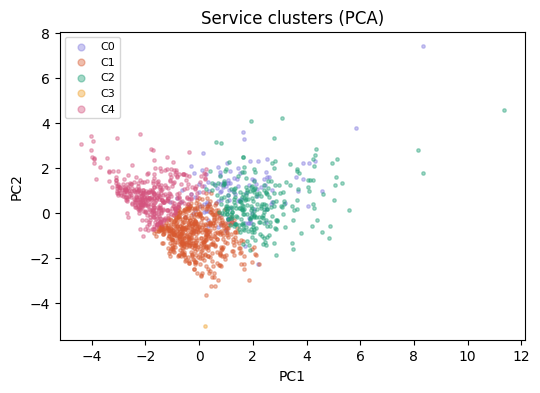

In [68]:
# -----------------------------
# 1. PCA cluster visualization
# -----------------------------
plt.figure(figsize=(6,4))

for c in range(K):
    m = behavior["cluster"] == c
    plt.scatter(behavior.loc[m,"pc1"],
                behavior.loc[m,"pc2"],
                alpha=0.4, s=6,
                color=colors[c],
                label=f"C{c}")

plt.title("Service clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(fontsize=8, markerscale=2)
plt.show()

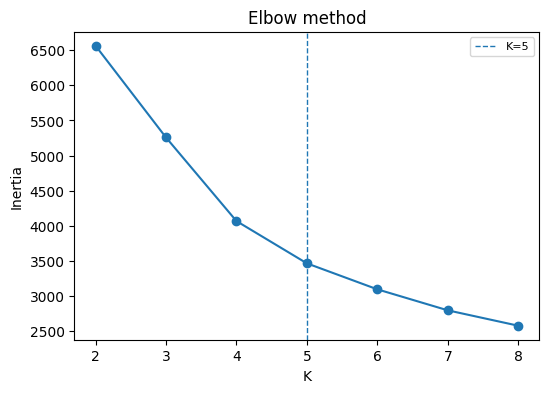

In [69]:

# -----------------------------
# 2. Elbow curve
# -----------------------------
plt.figure(figsize=(6,4))

plt.plot(list(K_range), inertias, "o-", lw=1.5)
plt.axvline(K, ls="--", lw=1, label=f"K={K}")

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.legend(fontsize=8)
plt.show()

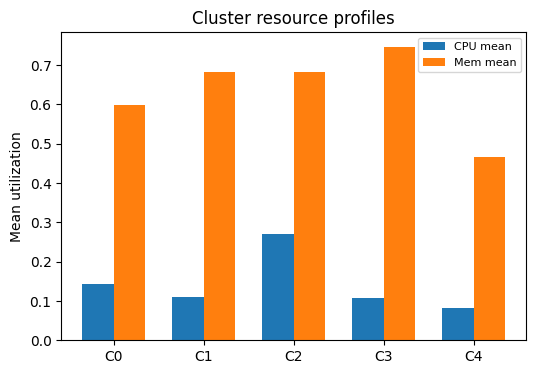

In [70]:
# -----------------------------
# 3. Cluster resource profiles
# -----------------------------
plt.figure(figsize=(6,4))

cm = behavior.groupby("cluster")[["cpu_mean","mem_mean"]].mean()

x = np.arange(K)
w = 0.35

plt.bar(x - w/2, cm["cpu_mean"], width=w, label="CPU mean")
plt.bar(x + w/2, cm["mem_mean"], width=w, label="Mem mean")

plt.xticks(x, [f"C{i}" for i in range(K)])
plt.ylabel("Mean utilization")
plt.title("Cluster resource profiles")
plt.legend(fontsize=8)

plt.show()

### GNN Readings

In [71]:
# print("\n" + "="*60)
# print("F. GNN READINESS REPORT")
# print("="*60)
 
# res_svcs   = load_resource().coalesce(16).select("msname").distinct()
# rtqps_svcs = load_rtqps().coalesce(16).select("msname").distinct()
 
# n_res   = res_svcs.count()
# n_rtqps = rtqps_svcs.count()
# n_graph = len(set(out_deg["DM"].values) | set(in_deg["UM"].values))
 
# # Services with traffic
# has_traffic = res_svcs.join(rtqps_svcs, on="msname", how="inner").count()
# # Services with graph edges
# graph_nodes = set(out_deg["DM"].values) | set(in_deg["UM"].values)
 
# res_pd = res_svcs.toPandas()
# has_graph = res_pd["msname"].isin(graph_nodes).sum()
 
# print(f"\nFeature coverage:")
# print(f"  Resource data (cpu+mem) : {n_res:,}  (100%)")
# print(f"  Traffic data (rtqps)    : {has_traffic:,}  "
#       f"({has_traffic/n_res*100:.1f}%)")
# print(f"  Graph edges             : {has_graph:,}  "
#       f"({has_graph/n_res*100:.1f}%)")
 
# # Temporal presence heatmap
# print("\n  Building temporal heatmap ...")
# BUCKET = 60
# hm_spark = (load_resource()
#     .coalesce(16)
#     .withColumn("bucket", (F.col("t_idx")/BUCKET).cast("int"))
#     .groupBy("msname","bucket")
#     .agg(F.mean("cpu_utilization").alias("cpu"))
#     .orderBy("msname","bucket"))
 
# sample_svcs = (load_resource()
#     .coalesce(16)
#     .select("msname").distinct()
#     .limit(80)
#     .toPandas()["msname"].tolist())
 
# hm_pd = (hm_spark
#     .filter(F.col("msname").isin(sample_svcs))
#     .toPandas()
#     .pivot(index="msname", columns="bucket", values="cpu"))
 
# fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# sns.heatmap(hm_pd.fillna(0), ax=axes[0], cmap="YlOrRd",
#             cbar_kws={"label":"Mean CPU"},
#             xticklabels=4, yticklabels=False)
# axes[0].set_title("CPU heatmap\n(80 services × 30-min buckets)")
# axes[0].set_xlabel("30-min bucket")
 
# sns.heatmap(hm_pd.notna().astype(int), ax=axes[1], cmap="Blues",
#             cbar_kws={"label":"Present"},
#             xticklabels=4, yticklabels=False)
# axes[1].set_title("Data presence\n(white = missing → needs imputation)")
# axes[1].set_xlabel("30-min bucket")
 
# plt.suptitle("F. GNN Feature Coverage", fontsize=12)
# plt.tight_layout()
# plt.savefig(f"{OUT_DIR}/F_gnn_coverage.png", dpi=150)
# plt.close()
# print(f"✓ Saved: {OUT_DIR}/F_gnn_coverage.png")


F. GNN READINESS REPORT



Feature coverage:
  Resource data (cpu+mem) : 1,303  (100%)
  Traffic data (rtqps)    : 1,303  (100.0%)
  Graph edges             : 0  (0.0%)

  Building temporal heatmap ...


✓ Saved: eda_advanced/F_gnn_coverage.png


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("F. GNN READINESS REPORT")
print("="*60)

res_svcs   = load_resource().coalesce(16).select("msname").distinct()
rtqps_svcs = load_rtqps().coalesce(16).select("msname").distinct()

n_res   = res_svcs.count()
n_rtqps = rtqps_svcs.count()
n_graph = len(set(out_deg["DM"].values) | set(in_deg["UM"].values))

# Services with traffic
has_traffic = res_svcs.join(rtqps_svcs, on="msname", how="inner").count()

# Services with graph edges
graph_nodes = set(out_deg["DM"].values) | set(in_deg["UM"].values)
res_pd = res_svcs.toPandas()
has_graph = res_pd["msname"].isin(graph_nodes).sum()

print(f"\nFeature coverage:")
print(f"  Resource data (cpu+mem) : {n_res:,}  (100%)")
print(f"  Traffic data (rtqps)    : {has_traffic:,}  "
      f"({has_traffic/n_res*100:.1f}%)")
print(f"  Graph edges             : {has_graph:,}  "
      f"({has_graph/n_res*100:.1f}%)")


F. GNN READINESS REPORT



Feature coverage:
  Resource data (cpu+mem) : 1,303  (100%)
  Traffic data (rtqps)    : 1,303  (100.0%)
  Graph edges             : 0  (0.0%)


In [73]:
# -----------------------------
# Build temporal heatmap
# -----------------------------
print("\n  Building temporal heatmap ...")

BUCKET = 60

hm_spark = (load_resource()
    .coalesce(16)
    .withColumn("bucket", (F.col("t_idx")/BUCKET).cast("int"))
    .groupBy("msname","bucket")
    .agg(F.mean("cpu_utilization").alias("cpu"))
    .orderBy("msname","bucket"))

sample_svcs = (load_resource()
    .coalesce(16)
    .select("msname").distinct()
    .limit(80)
    .toPandas()["msname"].tolist())

hm_pd = (hm_spark
    .filter(F.col("msname").isin(sample_svcs))
    .toPandas()
    .pivot(index="msname", columns="bucket", values="cpu"))


  Building temporal heatmap ...


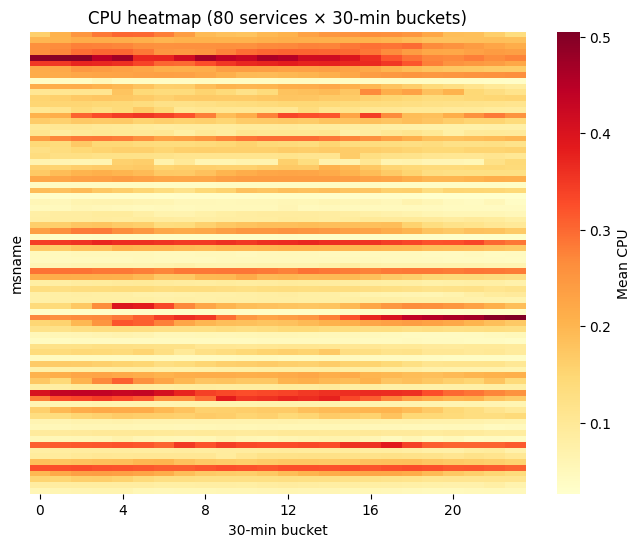

In [74]:
# -----------------------------
# 1. CPU heatmap
# -----------------------------
plt.figure(figsize=(8,6))

sns.heatmap(
    hm_pd.fillna(0),
    cmap="YlOrRd",
    cbar_kws={"label":"Mean CPU"},
    xticklabels=4,
    yticklabels=False
)

plt.title("CPU heatmap (80 services × 30-min buckets)")
plt.xlabel("30-min bucket")
plt.show()


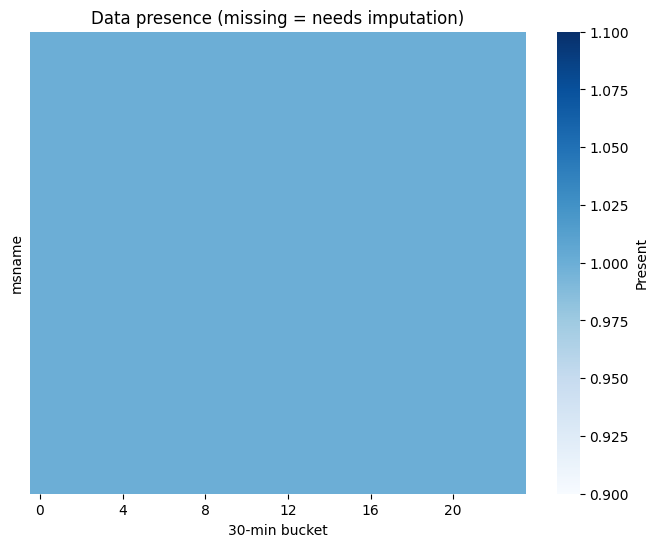

In [76]:
# -----------------------------
# 2. Data presence heatmap
# -----------------------------
plt.figure(figsize=(8,6))

sns.heatmap(
    hm_pd.notna().astype(int),
    cmap="Blues",
    cbar_kws={"label":"Present"},
    xticklabels=4,
    yticklabels=False
)

plt.title("Data presence (missing = needs imputation)")
plt.xlabel("30-min bucket")
plt.show()